In [ ]:
!pip install -qU triton torch

In [4]:
%%writefile profile_swiglu.py
import torch
import triton
import triton.language as tl


@triton.jit
def fused_swiglu_kernel(gate_ptr, up_ptr, out_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(axis=0)
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements

    gate = tl.load(gate_ptr + offsets, mask=mask).to(tl.float32)
    up = tl.load(up_ptr + offsets, mask=mask).to(tl.float32)

    sigmoid_gate = 1.0 / (1.0 + tl.exp(-gate))
    silu_gate = gate * sigmoid_gate
    result = silu_gate * up

    tl.store(out_ptr + offsets, result.to(tl.float16), mask=mask)

def triton_swiglu(gate, up):
    out = torch.empty_like(gate)
    n_elements = gate.numel()
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']), )
    fused_swiglu_kernel[grid](gate, up, out, n_elements, BLOCK_SIZE=1024)
    return out

# --- 2. Profile Execution ---
def main():
    gate = torch.randn(8, 2048, 4096, device='cuda', dtype=torch.float16)
    up = torch.randn(8, 2048, 4096, device='cuda', dtype=torch.float16)

    # Warmup
    _ = torch.nn.functional.silu(gate) * up
    _ = triton_swiglu(gate, up)
    torch.cuda.synchronize()

    # PyTorch Native execution
    out_torch = torch.nn.functional.silu(gate) * up
    torch.cuda.synchronize()

    # Triton execution
    out_triton = triton_swiglu(gate, up)
    torch.cuda.synchronize()

if __name__ == "__main__":
    main()

Writing profile_swiglu.py


In [ ]:
!apt-get update -y
!apt-get install -y nsight-compute nsight-systems

In [8]:
!ncu python profile_swiglu.py

==PROF== Connected to process 6709 (/usr/bin/python3.13)
==PROF== Profiling "distribution_elementwise_grid..." - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "distribution_elementwise_grid..." - 1: 0%....50%....100% - 9 passes
==PROF== Profiling "vectorized_elementwise_kernel" - 2: 0%....50%....100% - 9 passes
==PROF== Profiling "vectorized_elementwise_kernel" - 3: 0%....50%....100% - 9 passes
==PROF== Profiling "fused_swiglu_kernel" - 4: 0%....50%....100% - 9 passes
==PROF== Profiling "vectorized_elementwise_kernel" - 5: 0%....50%....100% - 9 passes
==PROF== Profiling "vectorized_elementwise_kernel" - 6: 0%....50%....100% - 9 passes
==PROF== Profiling "fused_swiglu_kernel" - 7: 0%....50%....100% - 9 passes
==PROF== Disconnected from process 6709
[6709] python3.13@127.0.0.1
  void at::<unnamed>::distribution_elementwise_grid_stride_kernel<float, 4, void templates::normal_and_transform<c10::Half, float, at::CUDAGeneratorImpl *, void templates::normal_kernel<at::CUDAGeneratorImpl *

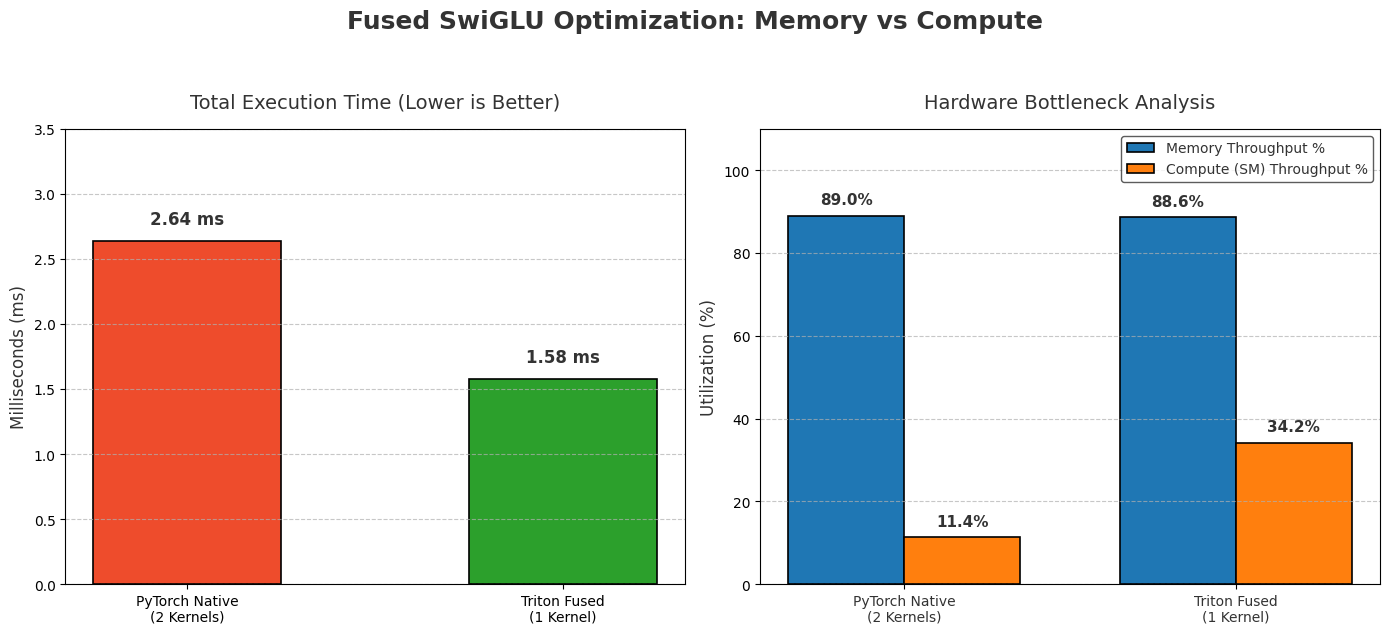

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Use a clean, professional white background style
plt.style.use('default')

# The exact data from your Nsight Compute profiling
methods = ['PyTorch Native\n(2 Kernels)', 'Triton Fused\n(1 Kernel)']
execution_times = [2.64, 1.58] # in ms

# Hardware Utilization Data
mem_util = [89.0, 88.6] # PyTorch bottleneck vs Triton
sm_util = [11.4, 34.2]  # PyTorch starved vs Triton utilized

# Set up the figure with a white background
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
fig.suptitle('Fused SwiGLU Optimization: Memory vs Compute', fontsize=18, fontweight='bold', y=1.05, color='#333333')

# --- CHART 1: Execution Time ---
# PyTorch Red/Orange and a crisp Green for the Fused kernel
bars1 = ax1.bar(methods, execution_times, color=['#EE4C2C', '#2CA02C'], width=0.5, edgecolor='black', linewidth=1.2)
ax1.set_title('Total Execution Time (Lower is Better)', fontsize=14, pad=15, color='#333333')
ax1.set_ylabel('Milliseconds (ms)', fontsize=12, color='#333333')
ax1.set_ylim(0, 3.5)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_facecolor('white')

# Add the numbers on top of the bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval} ms',
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

# --- CHART 2: Hardware Utilization ---
x = np.arange(len(methods))
width = 0.35

# Professional Blue and Orange for contrast
bars2_mem = ax2.bar(x - width/2, mem_util, width, label='Memory Throughput %', color='#1F77B4', edgecolor='black', linewidth=1.2)
bars2_sm = ax2.bar(x + width/2, sm_util, width, label='Compute (SM) Throughput %', color='#FF7F0E', edgecolor='black', linewidth=1.2)

ax2.set_title('Hardware Bottleneck Analysis', fontsize=14, pad=15, color='#333333')
ax2.set_ylabel('Utilization (%)', fontsize=12, color='#333333')
ax2.set_xticks(x)
ax2.set_xticklabels(methods, color='#333333')
ax2.set_ylim(0, 110)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_facecolor('white')

# Style the legend
legend = ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#333333')
for text in legend.get_texts():
    text.set_color('#333333')

# Add the numbers on top of these bars
for bar in bars2_mem + bars2_sm:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# Clean up layout and display
plt.tight_layout()
plt.show()